In [2]:
# ==========================================
# Machine Learning Password Strength Estimator
# Colab-ready implementation (Logistic Regression)
# Team: Nika Chorgoliani, Grigol Mikadze, Guram Lomidze
# ==========================================

import re
import math
import random
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import joblib

# ----------------------------
# 1) Helper functions
# ----------------------------

def estimate_entropy(password: str) -> float:
    """
    Simple entropy estimate based on the character pool size.
    Entropy ≈ L * log2(pool_size).
    This is a common approximation (not perfect, but useful for ML features).
    """
    if not password:
        return 0.0

    pool = 0
    if re.search(r"[a-z]", password): pool += 26
    if re.search(r"[A-Z]", password): pool += 26
    if re.search(r"[0-9]", password): pool += 10
    if re.search(r"[^a-zA-Z0-9]", password): pool += 33  # approx printable specials

    pool = max(pool, 1)
    return len(password) * math.log2(pool)

def extract_features(password: str) -> dict:
    """
    Convert a password string into numeric features for ML.
    """
    length = len(password)
    upper = sum(1 for c in password if c.isupper())
    lower = sum(1 for c in password if c.islower())
    digits = sum(1 for c in password if c.isdigit())
    specials = sum(1 for c in password if (not c.isalnum()))

    unique_chars = len(set(password)) if password else 0
    diversity_ratio = unique_chars / length if length > 0 else 0.0

    # simple pattern flags (common weak patterns)
    has_common_word = int(bool(re.search(r"(password|qwerty|admin|welcome|letmein|iloveyou)", password.lower())))
    has_repeats = int(bool(re.search(r"(.)\1\1", password)))  # 3 repeated chars
    has_sequence = int(bool(re.search(r"1234|2345|3456|4567|5678|6789|abcd|bcde|cdef", password.lower())))

    entropy = estimate_entropy(password)

    return {
        "length": length,
        "upper": upper,
        "lower": lower,
        "digits": digits,
        "specials": specials,
        "unique_chars": unique_chars,
        "diversity_ratio": diversity_ratio,
        "entropy": entropy,
        "has_common_word": has_common_word,
        "has_repeats": has_repeats,
        "has_sequence": has_sequence,
    }

# ----------------------------
# 2) Synthetic dataset generation
# ----------------------------

COMMON_WEAK = [
    "password", "qwerty", "admin", "welcome", "letmein",
    "iloveyou", "user", "login", "abc123", "123456", "111111"
]

def gen_weak_password() -> str:
    # Weak passwords: short, dictionary-like, predictable patterns
    base = random.choice(COMMON_WEAK)
    if random.random() < 0.5:
        base += str(random.randint(1, 999))
    if random.random() < 0.2:
        base = base.replace("a", "@").replace("o", "0")
    return base[:random.randint(5, 10)]

def gen_medium_password() -> str:
    # Medium passwords: moderate length, some digits/specials, still somewhat predictable
    letters = ''.join(random.choice(string.ascii_lowercase) for _ in range(random.randint(5, 8)))
    digits = ''.join(random.choice(string.digits) for _ in range(random.randint(1, 3)))
    specials = ''.join(random.choice("!@#$%") for _ in range(random.randint(0, 2)))
    mix = letters + digits + specials
    # capitalize sometimes
    if random.random() < 0.6:
        mix = mix.capitalize()
    return mix

def gen_strong_password() -> str:
    # Strong passwords: longer, high diversity, random mix
    length = random.randint(12, 18)
    pool = string.ascii_letters + string.digits + "!@#$%^&*()-_=+[]{};:,.?"
    pw = ''.join(random.choice(pool) for _ in range(length))
    return pw

def label_password(password: str) -> str:
    """
    Labeling logic for synthetic data:
    Weak: short/low entropy/common words
    Medium: moderate complexity
    Strong: high entropy and length and diversity
    """
    f = extract_features(password)
    # heuristic thresholds (for synthetic labels)
    if f["has_common_word"] == 1 or f["length"] < 8 or f["entropy"] < 30:
        return "weak"
    if f["length"] >= 12 and f["entropy"] >= 45 and f["diversity_ratio"] >= 0.6 and f["specials"] >= 1:
        return "strong"
    return "medium"

def build_dataset(n_per_class: int = 1500, seed: int = 42) -> pd.DataFrame:
    random.seed(seed)
    rows = []

    # generate roughly balanced classes
    for _ in range(n_per_class):
        pw = gen_weak_password()
        rows.append({"password": pw, "label": "weak"})

    for _ in range(n_per_class):
        pw = gen_medium_password()
        rows.append({"password": pw, "label": "medium"})

    for _ in range(n_per_class):
        pw = gen_strong_password()
        rows.append({"password": pw, "label": "strong"})

    df = pd.DataFrame(rows)

    # Optional: introduce a small amount of relabeling by heuristic to reduce "too-perfect" labels
    # (closer to real-world noise)
    if True:
        df["label"] = df["password"].apply(label_password)

    return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

df = build_dataset(n_per_class=1500, seed=42)
df.head()


,password,label
0,Ntanc120#,medium
1,63[8uoWxj(.y,strong
2,Ytpee9$#,medium
3,hqayfoj4#$,medium
4,123456,weak


In [3]:
# ----------------------------
# 3) Feature extraction -> ML dataset
# ----------------------------

feature_rows = [extract_features(pw) for pw in df["password"]]
X = pd.DataFrame(feature_rows)
y = df["label"]

print("Dataset size:", len(df))
print("Class distribution:\n", y.value_counts())

X.head()


Dataset size: 4500
Class distribution:
 label
strong    1639
weak      1547
medium    1314
Name: count, dtype: int64


,length,upper,lower,digits,specials,unique_chars,diversity_ratio,entropy,has_common_word,has_repeats,has_sequence
0,9,1,4,3,1,9,1.000,59.128700,0,0,0
1,12,1,5,3,3,12,1.000,78.838267,0,0,0
2,8,1,4,1,2,7,0.875,52.558845,0,0,0
3,10,0,7,1,2,10,1.000,61.085245,0,0,0
4,6,0,0,6,0,6,1.000,19.931569,0,0,1


In [4]:
# ----------------------------
# 4) Train/Test Split (70/30)
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train), "Test size:", len(X_test))


Train size: 3150 Test size: 1350


In [7]:
# ----------------------------
# 5) Model: Logistic Regression (with scaling)
# ----------------------------

pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        multi_class="auto",
        class_weight="balanced",
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))


Accuracy: 0.9867

Classification Report:

              precision    recall  f1-score   support

      medium     0.9796    0.9746    0.9771       394
      strong     0.9837    0.9837    0.9837       492
        weak     0.9957    1.0000    0.9978       464

    accuracy                         0.9867      1350
   macro avg     0.9863    0.9861    0.9862      1350
weighted avg     0.9866    0.9867    0.9867      1350



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


<Figure size 600x500 with 0 Axes>

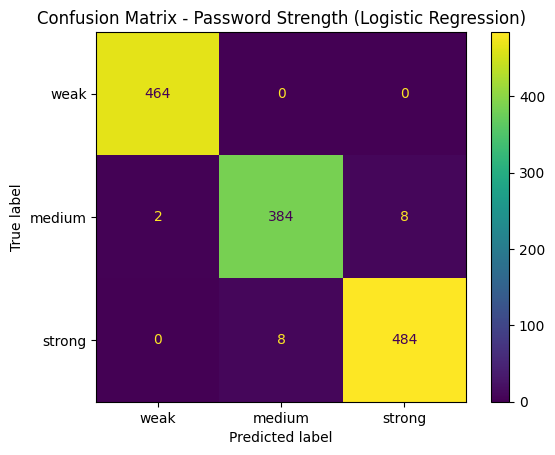

In [6]:
# ----------------------------
# 6) Confusion Matrix Plot
# ----------------------------

cm = confusion_matrix(y_test, y_pred, labels=["weak", "medium", "strong"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["weak", "medium", "strong"])

plt.figure(figsize=(6, 5))
disp.plot(values_format="d")
plt.title("Confusion Matrix - Password Strength (Logistic Regression)")
plt.show()


In [8]:
# ----------------------------
# 7) Feature Importance (approx via coefficients)
# ----------------------------
# Logistic Regression coefficients can be used to understand which features influence each class.

feature_names = X.columns.tolist()
clf = pipeline.named_steps["clf"]

coef_df = pd.DataFrame(clf.coef_, columns=feature_names, index=clf.classes_)
coef_df


,length,upper,lower,digits,specials,unique_chars,diversity_ratio,entropy,has_common_word,has_repeats,has_sequence
medium,0.234886,0.076799,0.853786,0.410758,-0.844670,0.390626,0.058498,1.107863,-2.244343,-0.202049,-0.197423
strong,3.650981,0.903947,1.591223,1.482175,3.025902,3.269729,-0.817598,4.351031,-0.352763,0.003915,-0.105863
weak,-3.885867,-0.980746,-2.445010,-1.892934,-2.181232,-3.660355,0.759100,-5.458895,2.597107,0.198133,0.303286


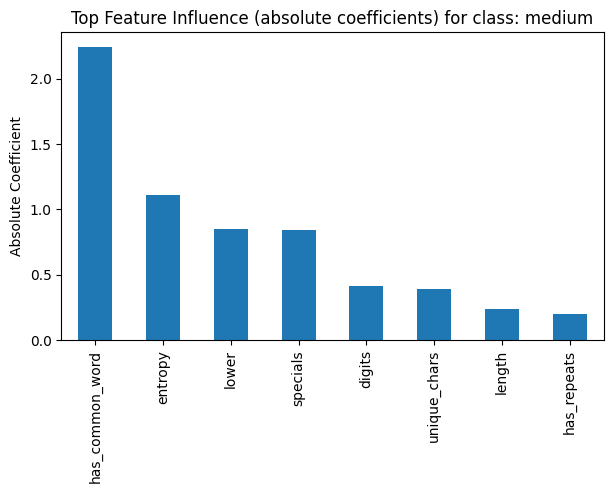

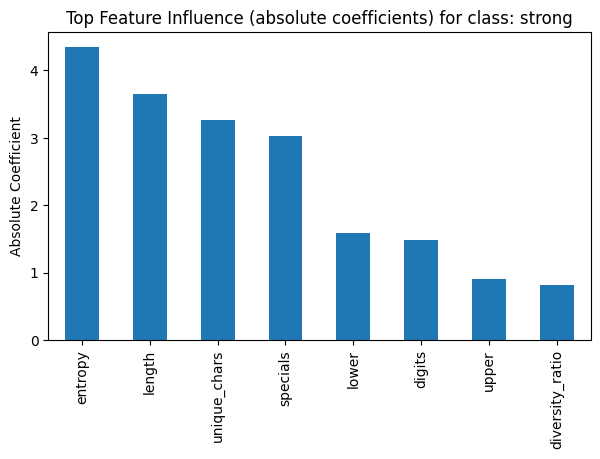

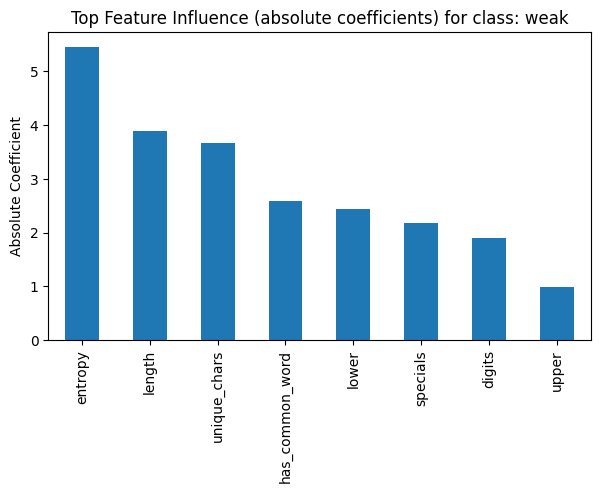

In [9]:
# Plot top influential features (by absolute coefficient) for each class
for cls in coef_df.index:
    top = coef_df.loc[cls].abs().sort_values(ascending=False).head(8)
    plt.figure(figsize=(7, 4))
    top.plot(kind="bar")
    plt.title(f"Top Feature Influence (absolute coefficients) for class: {cls}")
    plt.ylabel("Absolute Coefficient")
    plt.show()


In [10]:
# ----------------------------
# 8) Save model + example prediction
# ----------------------------

# Save the trained pipeline (scaler + model)
joblib.dump(pipeline, "password_strength_lr_model.joblib")
print("Saved model to: password_strength_lr_model.joblib")

# Example predictions
examples = [
    "password123",
    "Welcome2026",
    "N!kA-2026@StrongPass",
    "aB3$kL9@zQ1#"
]

example_features = pd.DataFrame([extract_features(pw) for pw in examples])
preds = pipeline.predict(example_features)

for pw, pred in zip(examples, preds):
    print(f"{pw:25s} -> {pred}")


Saved model to: password_strength_lr_model.joblib
password123               -> strong
Welcome2026               -> strong
N!kA-2026@StrongPass      -> strong
aB3$kL9@zQ1#              -> strong


In [ ]:
from google.colab import drive
drive.mount('/content/drive')